In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [101]:
train = pd.read_csv('train.csv')
public = pd.read_csv('public_test.csv')
private = pd.read_csv('private_test.csv')

## Exploratory Data Analysis

In [4]:
public

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,100001,50.0,65922.413596,3,Tablet,Organic,15,16,NaN,2,0,13,5698,1
1,100002,39.0,43205.865640,1,Mobile,Paid Ads,17,16,12.72,2,1,10,7011,0
2,100003,NaN,44333.908253,3,Mobile,Organic,17,15,3.13,5,0,21,8265,1
3,100004,22.0,141906.816221,3,Desktop,Social Media,1,2,25.32,3,0,9,5592,0
4,100005,47.0,39521.673456,1,Mobile,Social Media,2,4,NaN,3,1,9,4128,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,102996,44.0,67120.188908,2,Desktop,Organic,9,15,13.88,3,1,5,5987,1
2996,102997,NaN,101304.417703,3,Desktop,Organic,1,4,7.63,4,1,16,4807,0
2997,102998,49.0,NaN,1,Tablet,Social Media,15,13,11.42,2,0,8,8419,0
2998,102999,43.0,82385.919156,3,Tablet,Email,8,5,NaN,3,1,8,3138,0


In [11]:
public.groupby('City_Tier').Converted.mean()*100

City_Tier
1    30.987395
2    29.499218
3    27.792208
Name: Converted, dtype: float64

<Axes: xlabel='City_Tier'>

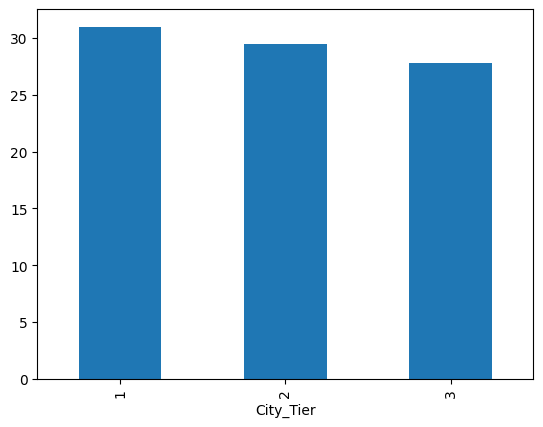

In [12]:
(public.groupby('City_Tier').Converted.mean()*100).plot(kind='bar')
#Conversion rate based on City Tier

np.float64(0.04200338631677056)

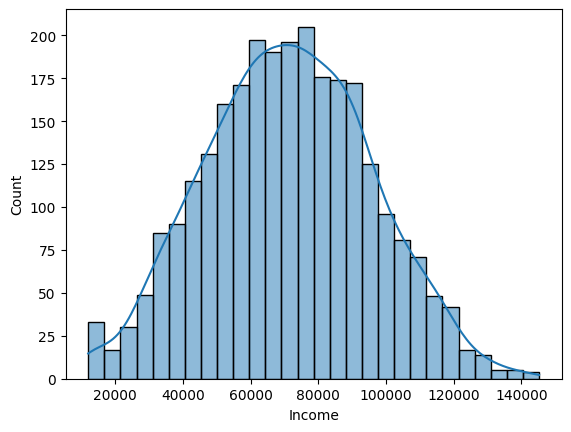

In [75]:
sns.histplot(public['Income'], kde=True)
public['Income'].skew()
#pretty symmteric distribution

<Axes: xlabel='Device_Type'>

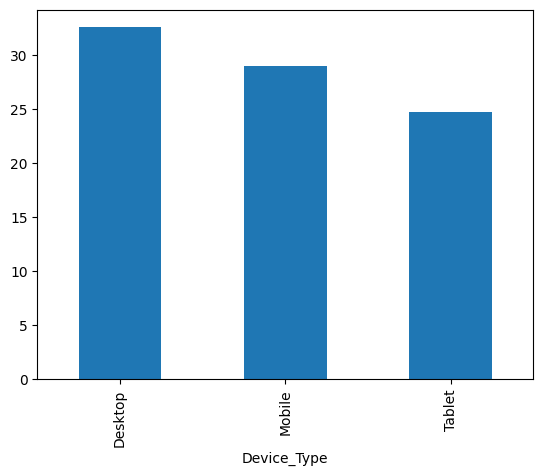

In [39]:
(public.groupby('Device_Type').Converted.mean()*100).plot(kind='bar')
#Conversion Rate based on Device type

<Axes: xlabel='Traffic_Source'>

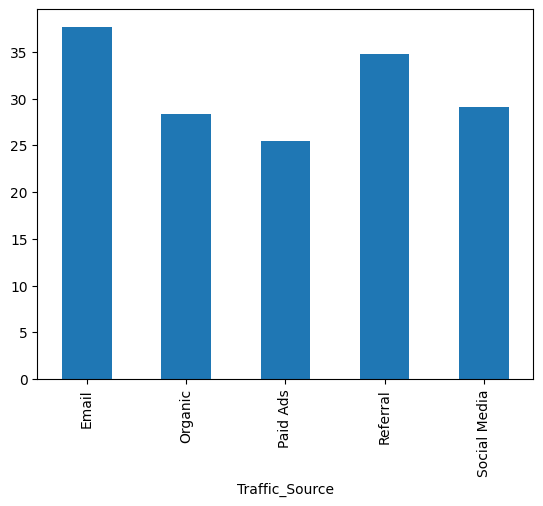

In [40]:
(public.groupby('Traffic_Source').Converted.mean()*100).plot(kind='bar')
#Conversion rate based on Traffic Source

np.float64(-0.03664539298950473)

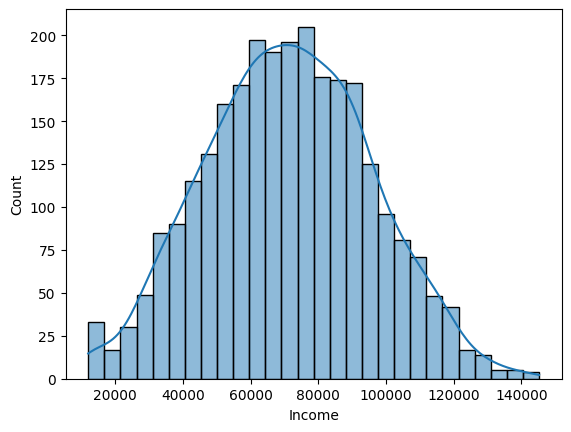

In [76]:
sns.histplot(public['Income'], kde=True)
public['Age'].skew()
#Symmetric Distribution

<Axes: xlabel='Pages_Viewed'>

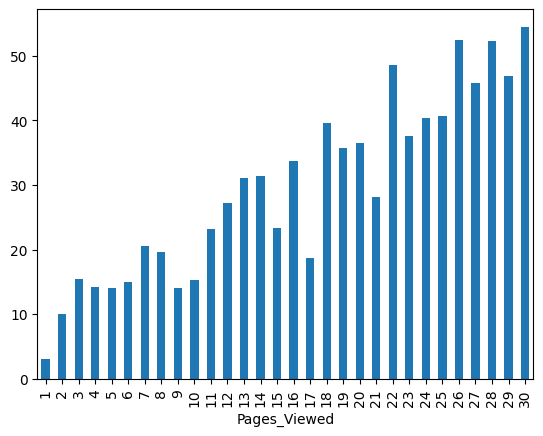

In [17]:
(public.groupby('Pages_Viewed').Converted.mean()*100).plot(kind='bar')

<Axes: xlabel='Products_Viewed'>

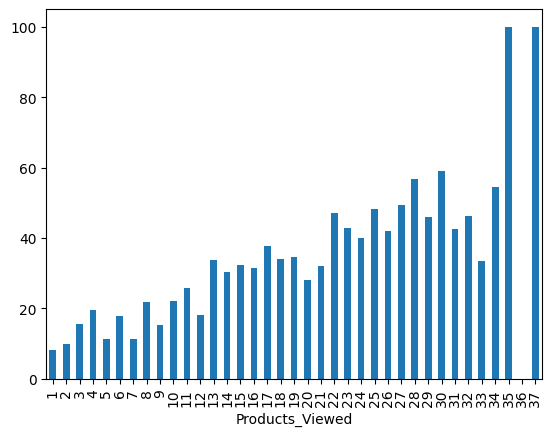

In [18]:
public.groupby('Products_Viewed').Converted.mean()*100).plot(kind='bar')

In [29]:
pd.crosstab(public['Previous_Purchases'],public['Converted'])

Converted,0,1
Previous_Purchases,,
0,105,39
1,347,97
2,471,164
3,503,184
4,346,166
5,203,129
6,86,55
7,37,34
8,12,13


<Axes: xlabel='Converted', ylabel='Previous_Purchases'>

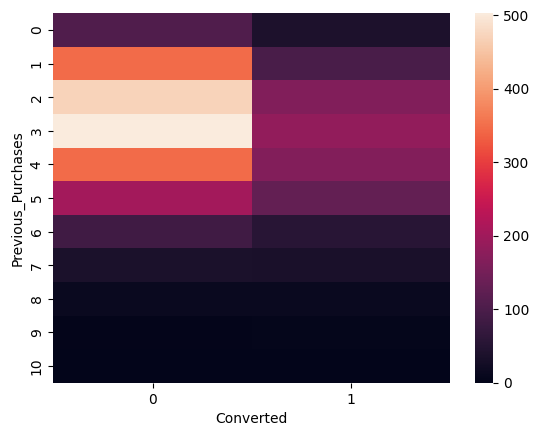

In [28]:
sns.heatmap(pd.crosstab(public['Previous_Purchases'],public['Converted']))

<Axes: xlabel='Previous_Purchases'>

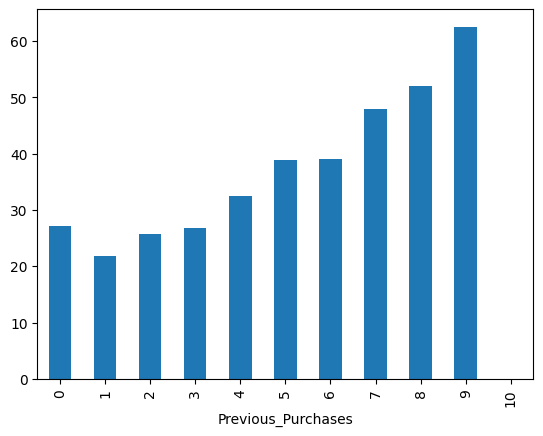

In [41]:
(public.groupby('Previous_Purchases').Converted.mean()*100).plot(kind='bar')
# Previous Purchases have a good impact on conversion rate

In [25]:
pd.crosstab(public['Browser_Version'],public['Converted'])
# Discounts has a 10%+- overall impact which is a huge factor

Converted,0,1
Browser_Version,,
1,83,44
2,98,39
3,80,36
4,84,39
5,84,32
6,86,36
7,79,38
8,96,30
9,87,34


<Axes: xlabel='Converted', ylabel='Browser_Version'>

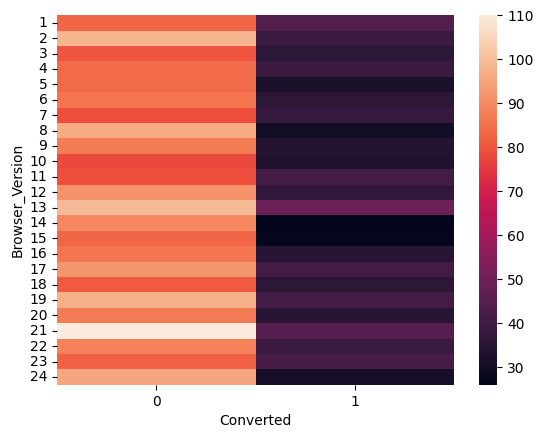

In [24]:
sns.heatmap(pd.crosstab(public['Browser_Version'],public['Converted']))
#From this we can infer that Browser version does not have that much impact

<Axes: xlabel='Converted', ylabel='Time_On_Site'>

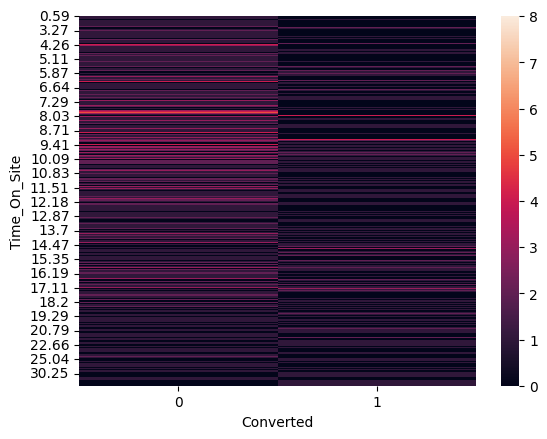

In [51]:
sns.heatmap(pd.crosstab(public['Time_On_Site'],public['Converted']))
#Time_On_Site has very less impact on Conversion rate

## Data Preprocessing

In [102]:
public['Device_Type_Encoded'] = public['Device_Type'].map({
    'Desktop':1,
    'Mobile':2,
    'Tablet':3
})
public['Traffic_Source_Encoded'] = public['Traffic_Source'].map({
    'Email':1,
    'Organic':2,
    'Paid Ads':3,
    'Referral':4,
    'Social Media':5
})
private['Device_Type_Encoded'] = private['Device_Type'].map({
    'Desktop':1,
    'Mobile':2,
    'Tablet':3
})
private['Traffic_Source_Encoded'] = private['Traffic_Source'].map({
    'Email':1,
    'Organic':2,
    'Paid Ads':3,
    'Referral':4,
    'Social Media':5
})
#TO get necessary columns into int forms to apply logic and model

In [47]:
public.isna().sum() #to check out how many Nan values are there in each column

User_ID                     0
Age                       472
Income                    301
City_Tier                   0
Device_Type                 0
Traffic_Source              0
Pages_Viewed                0
Products_Viewed             0
Time_On_Site              568
Previous_Purchases          0
Discount_Seen               0
Browser_Version             0
Campaign_Code               0
Converted                   0
Device_Type_Encoded         0
Traffic_Source_Encoded      0
dtype: int64

In [44]:
public['Age'].shape , public['Income'].shape , public['Time_On_Site'].shape

((3000,), (3000,), (3000,))

472/3000*100 = 15.73% missing values in Age column -- we can safely impute it

301/3000*100 = 10.0335% missing values in Income column -- we can safely impute it with mean since distribution is pretty symmetric

568/3000*100 = 18.93% missing values in Time_On_Site column -- we can drop it since it has many missing values and has less impact on Conversion rate

In [103]:
TARGET = ["Converted","Time_On_Site"]

# Separate features and target
X = public.drop(columns=TARGET)
y = public['Converted']

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_cols = X_train.select_dtypes(include = ['int64','float64']).columns.tolist()
X_train = X_train[numeric_cols]
X_val = X_val[numeric_cols]
X_private = private[numeric_cols]
numeric_cols # To review the columns that would be used in model for training

['User_ID',
 'Age',
 'Income',
 'City_Tier',
 'Pages_Viewed',
 'Products_Viewed',
 'Previous_Purchases',
 'Discount_Seen',
 'Browser_Version',
 'Campaign_Code',
 'Device_Type_Encoded',
 'Traffic_Source_Encoded']

## Model Training

In [104]:
# Filling missing values wiht Mean
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.fit_transform(X_val)
X_private_imputed = imputer.transform(X_private)

# Scaling features to mean = 0 and standard_deviation = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.fit_transform(X_val_imputed)
X_private_scaled = scaler.fit_transform(X_private_imputed)

In [105]:
#Training the Data Set
model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [106]:
predictions = model.predict(X_private_scaled)

train_acc = model.score(X_train_scaled, y_train)
val_acc = model.score(X_val_scaled,y_val)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Training Accuracy: 0.7225
Validation Accuracy: 0.7333


In [107]:
sample_submission = pd.DataFrame({
    "User_ID": private['User_ID'],
    'Converted': predictions
})

sample_submission

,User_ID,Converted
0,103001,0
1,103002,0
2,103003,0
3,103004,0
4,103005,0
...,...,...
2995,105996,0
2996,105997,0
2997,105998,1
2998,105999,0


In [109]:
sample_submission.to_csv("sample_submission.csv", index=False)